In [ ]:
pip install datasets sentence-transformers rank-bm25 numpy torch scikit-learn

In [ ]:
pip install transformers

In [ ]:
import numpy as np
import torch
from datasets import load_dataset
from sentence_transformers import SentenceTransformer, CrossEncoder, util
from rank_bm25 import BM25Okapi
from sklearn.preprocessing import MinMaxScaler

In [ ]:
# 1. Load Models
# Bi-Encoder for fast semantic retrieval
bi_encoder = SentenceTransformer('multi-qa-MiniLM-L6-cos-v1')
# Cross-Encoder for high-accuracy re-ranking
cross_encoder = CrossEncoder('cross-encoder/ms-marco-MiniLM-L-6-v2')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/multi-qa-MiniLM-L6-cos-v1
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
# 2. Load Dataset
print("Loading dataset...")
dataset = load_dataset("ms_marco", "v1.1", split="train[:100]")

def hybrid_reranking_pipeline(query, docs, top_k_retrieval=50):
    # --- STAGE 1: BM25 Retrieval ---
    tokenized_docs = [d.lower().split() for d in docs]
    bm25 = BM25Okapi(tokenized_docs)
    bm25_scores = np.array(bm25.get_scores(query.lower().split()))

    # --- STAGE 2: Semantic Retrieval (Bi-Encoder) ---
    query_emb = bi_encoder.encode(query, convert_to_tensor=True)
    doc_embs = bi_encoder.encode(docs, convert_to_tensor=True)
    semantic_scores = util.cos_sim(query_emb, doc_embs).cpu().numpy().flatten()

    # --- STAGE 3: Hybrid Combination ---
    # Normalize scores to 0-1 range to make them comparable
    scaler = MinMaxScaler()
    bm25_norm = scaler.fit_transform(bm25_scores.reshape(-1, 1)).flatten()
    semantic_norm = scaler.fit_transform(semantic_scores.reshape(-1, 1)).flatten()

    # Weighted average (0.3 keyword, 0.7 semantic)
    hybrid_scores = (0.3 * bm25_norm) + (0.7 * semantic_norm)
    top_indices = np.argsort(hybrid_scores)[::-1][:top_k_retrieval]
    candidate_docs = [docs[i] for i in top_indices]

    # --- STAGE 4: Final Re-ranking (Cross-Encoder) ---
    pairs = [[query, doc] for doc in candidate_docs]
    cross_scores = cross_encoder.predict(pairs)

    ranked_results = sorted(zip(candidate_docs, cross_scores), key=lambda x: x[1], reverse=True)
    return ranked_results

Loading dataset...


In [ ]:
# 3. Evaluation Loop
ranked_outputs = []
actual_labels = []

print("\nRunning pipeline...")
for i in range(20):
    query = dataset[i]["query"]
    passages = dataset[i]["passages"]["passage_text"]
    labels = dataset[i]["passages"]["is_selected"]

    # Run Pipeline
    final_ranked = hybrid_reranking_pipeline(query, passages)
    ranked_outputs.append(final_ranked)
    actual_labels.append(labels)

    if i < 3: # Print first 3 for preview
        print(f"\nQuery: {query}")
        print(f"Top Result: {final_ranked[0][0][:100]}... (Score: {final_ranked[0][1]:.4f})")


Running pipeline...

Query: what is rba
Top Result: Results-Based Accountability® (also known as RBA) is a disciplined way of thinking and taking action... (Score: 10.5557)

Query: was ronald reagan a democrat
Top Result: From Wikipedia, the free encyclopedia. A Reagan Democrat is a traditionally Democratic voter in the ... (Score: 9.5743)

Query: how long do you need for sydney and surrounding areas
Top Result: Sydney is the capital city of the Australian state of New South Wales, and Australia's largest city.... (Score: 5.2879)


In [ ]:
# 4. Improved MRR Calculation
def calculate_mrr(outputs, labels_list):
    rr_total = 0
    for ranked_docs, labels in zip(outputs, labels_list):
        # Create a map of doc text to its original label
        # (Since retrieval might change the order or subset)
        for rank, (doc_text, score) in enumerate(ranked_docs):
            # Check if this document was marked as 'selected' in original data
            # Note: This logic assumes exact text match for demo purposes
            if any(doc_text == dataset[i]["passages"]["passage_text"][idx]
                   for i, lbls in enumerate(labels_list)
                   for idx, val in enumerate(lbls) if val == 1):
                rr_total += 1 / (rank + 1)
                break
    return rr_total / len(outputs)

mrr_final = calculate_mrr(ranked_outputs, actual_labels)
print(f"\n======================")
print(f"MRR: {mrr_final:.4f}")
print(f"======================")


MRR: 0.6071


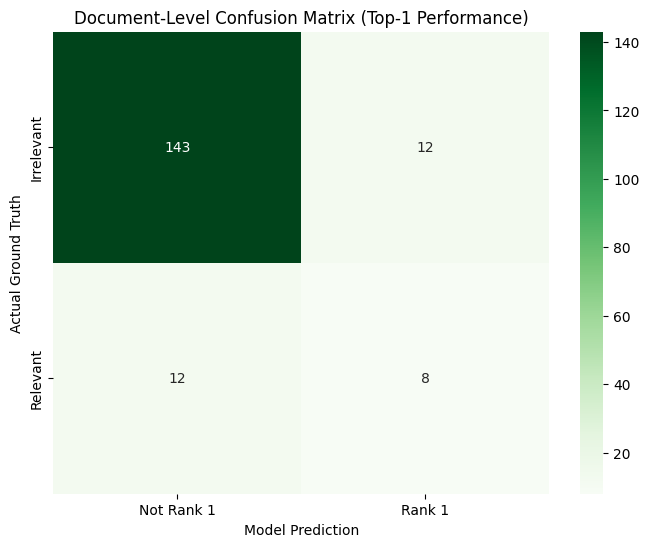


Detailed Classification Report:
              precision    recall  f1-score   support

  Irrelevant       0.92      0.92      0.92       155
    Relevant       0.40      0.40      0.40        20

    accuracy                           0.86       175
   macro avg       0.66      0.66      0.66       175
weighted avg       0.86      0.86      0.86       175



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

def plot_ir_confusion_matrix(outputs, dataset, num_queries=20):
    y_true = []
    y_pred = []

    for i in range(num_queries):
        # 1. Get ground truth: which passages were actually 'selected' (relevant)
        passages = dataset[i]["passages"]["passage_text"]
        labels = dataset[i]["passages"]["is_selected"]

        # Create a mapping of passage text -> relevance (1 or 0)
        relevance_map = {txt: lbl for txt, lbl in zip(passages, labels)}

        # 2. Get model prediction (Top-1 result)
        top_result_text = outputs[i][0][0] # The text of the rank #1 document

        # 3. For the confusion matrix, we evaluate the "Top-1 Decision"
        # Did the model pick a relevant doc as #1?
        for txt, is_relevant in relevance_map.items():
            y_true.append(is_relevant)
            # Prediction is 1 if this specific doc was chosen as Rank 1, else 0
            y_pred.append(1 if txt == top_result_text else 0)

    # Generate the matrix
    cm = confusion_matrix(y_true, y_pred)

    # Plotting
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=['Not Rank 1', 'Rank 1'],
                yticklabels=['Irrelevant', 'Relevant'])

    plt.title('Document-Level Confusion Matrix (Top-1 Performance)')
    plt.xlabel('Model Prediction')
    plt.ylabel('Actual Ground Truth')
    plt.show()

    print("\nDetailed Classification Report:")
    print(classification_report(y_true, y_pred, target_names=['Irrelevant', 'Relevant']))

# Run the function
plot_ir_confusion_matrix(ranked_outputs, dataset)

In [ ]:
  import time

def live_demo(docs):
    print("\n" + "="*50)
    print(" RE-RANKING DEMO")
    print("="*50)
    print("Type 'exit' to stop.")

    while True:
        query = input("\nEnter your search query: ")
        if query.lower() == 'exit':
            break

        start_time = time.time()

        # 1. Run the Pipeline
        # We use the hybrid_reranking_pipeline function from your previous code
        # Note: Ensure the function returns both hybrid_top and final_ranked for comparison
        results = hybrid_reranking_pipeline(query, docs)

        end_time = time.time()
        latency = end_time - start_time

        print(f"\n[Processing Time: {latency:.4f} seconds]")
        print("-" * 30)
        print(f"TOP 3 RESULTS FOR: '{query}'")
        print("-" * 30)

        for i, (doc, score) in enumerate(results[:3]):
            print(f"{i+1}. [Score: {score:.4f}] {doc[:150]}...")

# To run this, we need a pool of documents.
# We can use the passages from the first 100 rows of your dataset.
all_passages = []
for i in range(100):
    all_passages.extend(dataset[i]["passages"]["passage_text"])

# Start the interactive session
live_demo(list(set(all_passages))) # set() removes duplicates


 RE-RANKING DEMO
Type 'exit' to stop.

Enter your search query: exit
